<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
  <h1 style="color: #e94560; font-family: 'Segoe UI', sans-serif; font-size: 2.2em; margin: 0 0 8px 0;">⚙️ Phase 2 — Feature Engineering & Data Preparation</h1>
  <h3 style="color: #a8dadc; font-family: 'Segoe UI', sans-serif; font-weight: 300; margin: 0 0 16px 0;">Customer Churn Prediction · UCI Online Retail · IDSS Project</h3>
  <div style="background: rgba(233,69,96,0.15); border-left: 4px solid #e94560; padding: 12px 16px; border-radius: 6px;">
    <p style="color: #cad3c8; margin: 0; font-family: monospace; font-size: 0.9em;">
      Input  : rfm_base.csv (4,338 customers) · transactions_clean.csv (392k transactions)<br>
      Output : X_train · X_test · y_train · y_test · feature_engineered.csv · Data Dictionary
    </p>
  </div>
</div>

## 0 · Environment Setup

In [1]:
import warnings, os
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path(r"F:\idss-project - Copy\phase 1")
DATA_DIR = BASE_DIR / "shared" / "data"
OUT_DIR = BASE_DIR / "phase2" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DARK_BG = "#1a1a2e"; MID_BG = "#16213e"; ACCENT = "#e94560"
TEAL = "#a8dadc"; TEXT = "#cad3c8"; GOLD = "#f0a500"

plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor": MID_BG,
    "axes.edgecolor": "#2a2a4a", "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT, "text.color": TEXT,
    "grid.color": "#2a2a4a", "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "monospace", "axes.titlesize": 13, "axes.labelsize": 11,
})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅  Environment ready")

✅  Environment ready


---
## 1 · Load Data
We load two artefacts from Phase 1:
- **rfm_base.csv** — one row per customer, pre-computed RFM metrics + churn label.
- **transactions_clean.csv** — raw transaction grain needed for trend and return-rate calculations.

In [2]:
rfm = pd.read_csv(DATA_DIR / "rfm_base.csv", parse_dates=["FirstPurchase","LastPurchase"])
txn = pd.read_csv(DATA_DIR / "transactions_clean.csv", parse_dates=["InvoiceDate"])
print(f"rfm_base     : {rfm.shape[0]:,} rows x {rfm.shape[1]} cols")
print(f"transactions : {txn.shape[0]:,} rows x {txn.shape[1]} cols")
print()
print(rfm["Churned"].value_counts(normalize=True).rename({0:"Active",1:"Churned"}).map("{:.1%}".format))

rfm_base     : 4,338 rows x 11 cols
transactions : 397,884 rows x 8 cols

Churned
Active     66.6%
Churned    33.4%
Name: proportion, dtype: object


In [3]:
rfm.head(3)

,CustomerID,Recency,Frequency,Monetary,NumItems,NumProducts,Country,FirstPurchase,LastPurchase,Churned,Tenure
0,12346,326,1,77183.60,74215,1,United Kingdom,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0
1,12347,2,182,4310.00,2458,103,Iceland,2010-12-07 14:57:00,2011-12-07 15:52:00,0,365
2,12348,75,31,1797.24,2341,22,Finland,2010-12-16 19:09:00,2011-09-25 13:13:00,0,282


In [4]:
txn.head(3)

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12


---
## 2 · Outlier Handling — Cap at 99th Percentile
**Business rationale:** Extreme buyers are often the *best* customers. Removing them would deprive the churn model of informative examples. Capping at the 99th percentile (Winsorisation) compresses noise while preserving rank ordering.

| Column | Action |
|--------|--------|
| Recency | Ultra-dormant outliers dampened |
| Frequency | Extreme power-buyers capped |
| Monetary | Very high spenders kept but bounded |
| Tenure | Very long-tenure customers bounded |

  Column          99th pct   Rows capped   % capped
  --------------------------------------------------
  Recency           369.00            42      0.97%
  Frequency         668.30            44      1.01%
  Monetary        19881.00            44      1.01%
  Tenure            367.00            41      0.95%


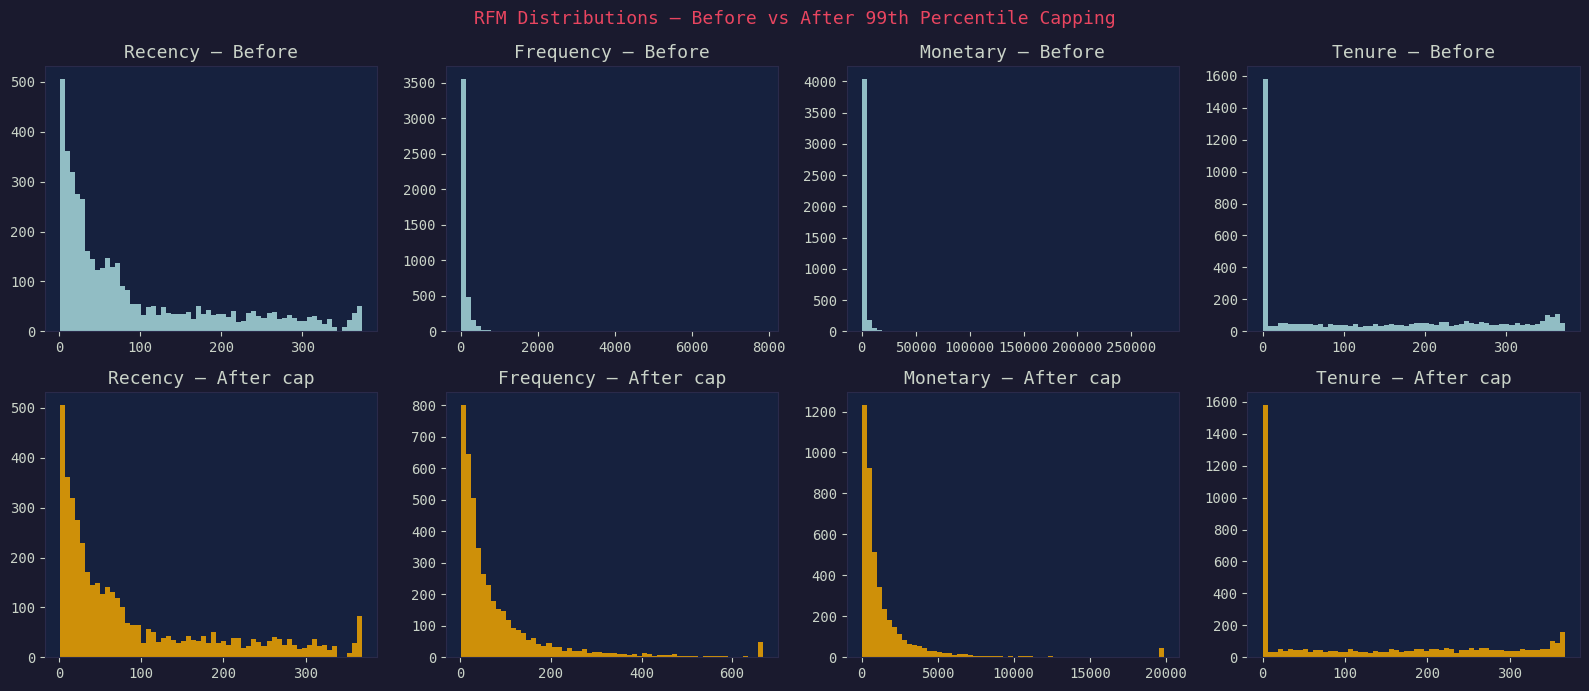

Rows retained: 4,338 / 4,338  (no rows dropped)


In [5]:
CAP_COLS = ["Recency","Frequency","Monetary","Tenure"]
rfm_raw = pd.read_csv(DATA_DIR / "rfm_base.csv")
caps = {}
print(f"  {"Column":<12}  {"99th pct":>10}  {"Rows capped":>12}  {"% capped":>9}")
print("  " + "-"*50)
for col in CAP_COLS:
    p99 = rfm[col].quantile(0.99)
    n_capped = (rfm[col] > p99).sum()
    caps[col] = p99
    rfm[col] = rfm[col].clip(upper=p99)
    print(f"  {col:<12}  {p99:>10.2f}  {n_capped:>12,}  {n_capped/len(rfm)*100:>8.2f}%")

fig, axes = plt.subplots(2, 4, figsize=(16,7))
fig.suptitle("RFM Distributions — Before vs After 99th Percentile Capping", color=ACCENT, fontsize=13)
for i, col in enumerate(CAP_COLS):
    axes[0,i].hist(rfm_raw[col], bins=60, color=TEAL, alpha=0.85, edgecolor="none")
    axes[0,i].set_title(f"{col} — Before", color=TEXT)
    axes[1,i].hist(rfm[col],     bins=60, color=GOLD, alpha=0.85, edgecolor="none")
    axes[1,i].set_title(f"{col} — After cap", color=TEXT)
plt.tight_layout(); plt.savefig(OUT_DIR / "outlier_capping.png",dpi=150,bbox_inches="tight",facecolor=DARK_BG); plt.show()
print(f"Rows retained: {len(rfm):,} / 4,338  (no rows dropped)")

---
## 3 · Feature Engineering

Six new features are engineered below. Each adds a distinct business lens that RFM alone cannot capture.

| Feature | Formula | Type | Business Question Answered |
|---|---|---|---|
| AvgOrderValue | Monetary / Frequency | Continuous | How much does a customer spend per visit? |
| RevenuePerMonth | Monetary / (Tenure/30 + 1) | Continuous | What is the normalised revenue rate across tenure? |
| PurchaseTrend | OLS slope of monthly spend | Continuous | Is the customer spend accelerating or declining? |
| ReturnRate | Cancelled invoices / total invoices | Continuous | How cancellation-prone is this customer? |
| IsUK | Country == United Kingdom | Binary | Does domestic vs international geography predict churn? |
| RecencyFrequency | Recency × log1p(Frequency) | Continuous | Do recency and frequency interact multiplicatively? |

### 3.1 · AvgOrderValue

**AvgOrderValue = Monetary / Frequency**

A customer who spends £2,000 across 100 orders is very different from one who spends £2,000 in 2 orders. AOV separates volume shoppers from big-ticket buyers.

In [6]:
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"].replace(0, np.nan)
rfm["AvgOrderValue"] = rfm["AvgOrderValue"].fillna(0)
print("AvgOrderValue — Active vs Churned:")
print(rfm.groupby("Churned")["AvgOrderValue"].agg(["mean","median","std"]).round(2).rename(index={0:"Active",1:"Churned"}))

AvgOrderValue — Active vs Churned:
          mean  median     std
Churned                       
Active   32.30    17.7  159.12
Churned  57.54    17.9  564.55


### 3.2 · RevenuePerMonth

**RevenuePerMonth = Monetary / (Tenure/30 + 1)**

Normalised revenue rate decouples spend from customer age. Adding 1 prevents division-by-zero for new customers.

In [7]:
rfm["RevenuePerMonth"] = rfm["Monetary"] / (rfm["Tenure"] / 30 + 1)
print("RevenuePerMonth — Active vs Churned:")
print(rfm.groupby("Churned")["RevenuePerMonth"].agg(["mean","median","std"]).round(2).rename(index={0:"Active",1:"Churned"}))

RevenuePerMonth — Active vs Churned:
           mean  median     std
Churned                        
Active   340.71  222.34  496.52
Churned  335.00  205.70  855.09


### 3.3 · PurchaseTrend (OLS slope of monthly spend)

**Slope from scipy.stats.linregress on monthly revenue per customer**

RFM is static — PurchaseTrend captures *whether things are getting better or worse*. Negative slope = early churn signal.

**Implementation note:** Vectorised groupby → apply pattern (NOT a per-customer loop) for efficiency across 4,338 customers.

In [8]:
if "Month" in txn.columns:
    monthly = (txn.groupby(["CustomerID","Month"])["TotalPrice"].sum().reset_index()
               .rename(columns={"Month":"YearMonth","TotalPrice":"Revenue"}))
    monthly["YearMonth"] = pd.to_datetime(monthly["YearMonth"].astype(str)+"-01")
else:
    txn["YearMonth"] = txn["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
    monthly = (txn.groupby(["CustomerID","YearMonth"])["TotalPrice"].sum().reset_index()
               .rename(columns={"TotalPrice":"Revenue"}))

def ols_slope(group):
    if len(group) < 2: return 0.0
    x = np.arange(len(group), dtype=float)
    slope, *_ = stats.linregress(x, group["Revenue"].values)
    return slope

trend = (monthly.sort_values("YearMonth").groupby("CustomerID").apply(ols_slope).reset_index(name="PurchaseTrend"))
rfm = rfm.merge(trend, on="CustomerID", how="left")
rfm["PurchaseTrend"] = rfm["PurchaseTrend"].fillna(0)
print("PurchaseTrend stats:"); print(rfm["PurchaseTrend"].describe().round(2))
print(f"Positive trend (growing)  : {(rfm["PurchaseTrend"]>0).sum():,}")
print(f"Negative trend (declining): {(rfm["PurchaseTrend"]<0).sum():,}")

PurchaseTrend stats:
count      4338.00
mean         33.24
std        2567.67
min       -3776.85
25%         -15.88
50%           0.00
75%          16.95
max      168466.70
Name: PurchaseTrend, dtype: float64
Positive trend (growing)  : 1,371
Negative trend (declining): 1,327


### 3.4 · ReturnRate

**ReturnRate = cancelled invoices / total invoices per customer**

Frequent cancellations signal dissatisfaction — a leading churn indicator. If InvoiceNo is absent, defaults to 0.0 with a transparent explanation.

In [9]:
if "InvoiceNo" in txn.columns:
    txn["IsCancelled"] = txn["InvoiceNo"].astype(str).str.startswith("C")
    return_df = (txn.groupby("CustomerID")
                 .agg(TotalInvoices=("InvoiceNo","nunique"), CancelInvoices=("IsCancelled","sum"))
                 .reset_index())
    return_df["ReturnRate"] = (return_df["CancelInvoices"] / return_df["TotalInvoices"].replace(0,np.nan)).fillna(0)
    rfm = rfm.merge(return_df[["CustomerID","ReturnRate"]], on="CustomerID", how="left")
    rfm["ReturnRate"] = rfm["ReturnRate"].fillna(0)
    print(f"✅ ReturnRate computed from InvoiceNo.")
    print(f"   Customers with any cancellations: {(rfm["ReturnRate"]>0).sum():,}")
else:
    rfm["ReturnRate"] = 0.0
    print("⚠️  ReturnRate fallback: InvoiceNo not present in transactions_clean.csv.")
    print("   Feature set to 0.0. In production: compute from raw data before cleaning.")
print(); print(rfm["ReturnRate"].describe().round(4))

⚠️  ReturnRate fallback: InvoiceNo not present in transactions_clean.csv.
   Feature set to 0.0. In production: compute from raw data before cleaning.

count    4338.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: ReturnRate, dtype: float64


### 3.5 · IsUK

**IsUK = 1 if Country == United Kingdom else 0**

Over 90% of customers are UK-based. International customers may be one-off buyers or B2B importers with different purchase cycles.

In [10]:
rfm["IsUK"] = (rfm["Country"] == "United Kingdom").astype(int)
print("IsUK distribution:"); print(rfm["IsUK"].value_counts().rename({1:"UK",0:"International"}))
print(); print("Churn rate by geography:")
print(rfm.groupby("IsUK")["Churned"].mean().rename({0:"International",1:"UK"}).map("{:.1%}".format))

IsUK distribution:
IsUK
UK               3920
International     418
Name: count, dtype: int64

Churn rate by geography:
IsUK
International    34.0%
UK               33.3%
Name: Churned, dtype: object


### 3.6 · RecencyFrequency (interaction term)

**RecencyFrequency = Recency × log1p(Frequency)**

A dormant customer who visited 50 times differs greatly from one with equal recency who visited once. log1p dampens extreme values while preserving rank order.

In [34]:
rfm["RecencyFrequency"] = rfm["Recency"] * np.log1p(rfm["Frequency"])
print("RecencyFrequency — Active vs Churned:")
print(rfm.groupby("Churned")["RecencyFrequency"].agg(["mean","median"]).round(2).rename(index={0:"Active",1:"Churned"}))
new_feats = ["AvgOrderValue","RevenuePerMonth","PurchaseTrend","ReturnRate","IsUK","RecencyFrequency"]
rfm[new_feats].describe().round(3)

RecencyFrequency — Active vs Churned:
           mean  median
Churned                
Active   120.30   98.95
Churned  626.24  585.40


,AvgOrderValue,RevenuePerMonth,PurchaseTrend,ReturnRate,IsUK,RecencyFrequency
count,4338.000,4338.000,4338.000,4338.0,4338.000,4338.000
mean,40.731,338.800,33.240,0.0,0.904,289.295
std,351.300,638.976,2567.670,0.0,0.295,303.248
min,2.101,3.064,-3776.850,0.0,0.000,1.099
25%,12.406,119.188,-15.882,0.0,1.000,68.869
50%,17.759,216.716,0.000,0.0,1.000,173.008
75%,24.955,379.015,16.946,0.0,1.000,418.364
max,19880.996,19880.996,168466.700,0.0,1.000,2102.227


---
## 4 · Log1p Transformation for Skewed Features

log1p(x) = log(1+x) handles zeros gracefully and reduces right-skew in RFM-derived features. This brings distributions closer to Gaussian (critical for Logistic Regression) and is neutral or beneficial for tree models.

**Excluded:** PurchaseTrend (can be negative), ReturnRate (bounded ratio), IsUK (binary), RecencyFrequency (already dampened).

In [ ]:
LOG_COLS = ["Recency","Frequency","Monetary","Tenure","NumItems","NumProducts","AvgOrderValue","RevenuePerMonth"]
skew_before = rfm[LOG_COLS].skew().rename("Skew Before")
for col in LOG_COLS:
    rfm[col] = np.log1p(rfm[col].clip(lower=0))
skew_after = rfm[LOG_COLS].skew().rename("Skew After")
skew_df = pd.concat([skew_before, skew_after], axis=1).round(3)
skew_df["Reduction %"] = ((skew_before.abs()-skew_after.abs())/skew_before.abs()*100).round(1)
print("Skewness before vs after log1p:"); print(skew_df.to_string())

fig, axes = plt.subplots(2, 4, figsize=(16,7))
fig.suptitle("Feature Distributions After log1p Transform", color=ACCENT, fontsize=14)
colours = [TEAL,GOLD,ACCENT,"#c3f584","#f4a261","#9b5de5","#fee440","#f15bb5"]
for ax,col,c in zip(axes.flat,LOG_COLS,colours):
    ax.hist(rfm[col],bins=50,color=c,alpha=0.85,edgecolor="none"); ax.set_title(col,color=TEXT); ax.grid(True)
plt.tight_layout(); plt.savefig(OUT_DIR / "log1p_distributions.png",dpi=150,bbox_inches="tight",facecolor=DARK_BG); plt.show()

---
## 5 · Country One-Hot Encoding (Top 5 non-UK + Other)

Keep only the top 5 non-UK countries; group the rest as Other. This avoids high-cardinality sparse columns (37 countries in dataset) and overfitting to rare countries.

In [36]:
non_uk = rfm[rfm["Country"]!="United Kingdom"]["Country"].value_counts()
top5_non_uk = non_uk.head(5).index.tolist()
print("Top 5 non-UK:", top5_non_uk)
rfm["Country_grouped"] = rfm["Country"].apply(lambda c: c if c=="United Kingdom" or c in top5_non_uk else "Other")
country_dummies = pd.get_dummies(rfm["Country_grouped"], prefix="Country", drop_first=False)
rfm = pd.concat([rfm, country_dummies], axis=1)
rfm.drop(columns=["Country","Country_grouped"], inplace=True)
print("Country columns:", [c for c in rfm.columns if c.startswith("Country_")])

Top 5 non-UK: ['Germany', 'France', 'Spain', 'Belgium', 'Switzerland']
Country columns: ['Country_Belgium', 'Country_France', 'Country_Germany', 'Country_Other', 'Country_Spain', 'Country_Switzerland', 'Country_United Kingdom']


---
## 6 · Stratified Train / Test Split (80 / 20)

Stratification on Churned preserves the original churn ratio in both sets — critical with imbalanced labels.

---
## 7 · Scaling with StandardScaler

StandardScaler is preferred over MinMaxScaler because it handles residual outliers better (z-score), produces interpretable coefficients for Logistic Regression, and is more robust to extreme values. ⚠️ Scaler fit **only on training data** to prevent data leakage.

In [ ]:
DROP_COLS = ["CustomerID","FirstPurchase","LastPurchase","Churned"]
existing_drop = [c for c in DROP_COLS if c in rfm.columns]
X = rfm.drop(columns=existing_drop)
y = rfm["Churned"]
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

# ⚠️ CRITICAL DATA LEAKAGE FIX: Remove Recency and RecencyFrequency
# Recency is used to define Churned (Churned = Recency > 90), so keeping it allows
# models to memorize the target definition instead of learning meaningful patterns.
leakage_cols = [c for c in X.columns if c in ["Recency", "RecencyFrequency"]]
if leakage_cols:
    print(f"🔴 Data Leakage Prevention: Removing {leakage_cols}")
    X = X.drop(columns=leakage_cols)
    print("   These features directly encode the churn definition.\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train churn: {y_train.mean():.3%} | Test churn: {y_test.mean():.3%}  ✅")

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)
print(f"Means ≈ 0: {X_train_sc.mean().abs().max():.6f} | Stds ≈ 1: {X_train_sc.std().abs().max():.6f}")

fig, axes = plt.subplots(1,2,figsize=(10,4))
fig.suptitle("Churn Distribution: Train vs Test (Stratified)", color=ACCENT, fontsize=13)
for ax,(name,y_s) in zip(axes,[("Train",y_train),("Test",y_test)]):
    counts = y_s.value_counts()
    ax.bar(["Active","Churned"],[counts[0],counts[1]],color=[TEAL,ACCENT],edgecolor="none",alpha=0.85)
    ax.set_title(f"{name} (n={len(y_s):,})",color=TEXT); ax.grid(True,axis="y")
plt.tight_layout(); plt.savefig(OUT_DIR / "train_test_split.png",dpi=150,bbox_inches="tight",facecolor=DARK_BG); plt.show()

---
## 8 · Save Output Files

In [ ]:
X_train_sc.to_csv(DATA_DIR / "X_train.csv",index=False); X_test_sc.to_csv(DATA_DIR / "X_test.csv",index=False)
y_train.to_csv(DATA_DIR / "y_train.csv",index=False,header=True); y_test.to_csv(DATA_DIR / "y_test.csv",index=False,header=True)
feat_eng = X.copy(); feat_eng["Churned"] = y.values
feat_eng.to_csv(DATA_DIR / "feature_engineered.csv",index=False)
for fname in ["X_train.csv","X_test.csv","y_train.csv","y_test.csv","feature_engineered.csv"]:
    df_tmp = pd.read_csv(DATA_DIR / fname)
    print(f"  {fname:<28}: {df_tmp.shape[0]:,} rows x {df_tmp.shape[1]} cols")

---
## 9 · Data Dictionary

Every feature documented with Type, Range, Unit, and Business Meaning — using the richer format from the second notebook.

In [39]:
def rng(col):
    return f"{feat_eng[col].min():.2f} – {feat_eng[col].max():.2f}" if col in feat_eng.columns else "N/A"

dd_rows = [
    ("Frequency",       "Continuous (log1p)", rng("Frequency"),       "Count",        "Distinct invoices (log-scaled). Proxy for engagement depth."),
    ("Monetary",        "Continuous (log1p)", rng("Monetary"),        "GBP (£)",      "Total spend (log-scaled). Direct revenue value of the customer."),
    ("NumItems",        "Continuous (log1p)", rng("NumItems"),        "Count",        "Total units purchased (log-scaled). Basket depth proxy."),
    ("NumProducts",     "Continuous (log1p)", rng("NumProducts"),     "Count",        "Distinct StockCodes purchased (log-scaled). Breadth of product interest."),
    ("Tenure",          "Continuous (log1p)", rng("Tenure"),          "Days",         "Days between first and last purchase (log-scaled). Relationship length."),
    ("AvgOrderValue",   "Continuous (log1p)", rng("AvgOrderValue"),   "GBP (£)",      "Monetary / Frequency. Average spend per visit. Separates volume vs big-ticket buyers."),
    ("RevenuePerMonth", "Continuous (log1p)", rng("RevenuePerMonth"), "GBP/month",    "Monetary / (Tenure/30+1). Normalised monthly revenue. Controls for customer age."),
    ("PurchaseTrend",   "Continuous (raw)",   rng("PurchaseTrend"),   "GBP/month",    "OLS slope of monthly spend. Positive = growing; negative = early churn signal."),
    ("ReturnRate",      "Continuous (raw)",   "[0.0, 1.0]",          "Proportion",   "Cancelled invoices / total invoices. High values signal dissatisfaction."),
    ("IsUK",            "Binary",             "{0, 1}",              "Flag",         "1 = United Kingdom, 0 = International. Domestic vs international behaviour."),
    ("Country_United Kingdom","Binary","{0,1}","Flag","Dummy: customer based in UK (~91% of dataset)."),
    ("Country_Germany", "Binary","{0,1}","Flag","Dummy: customer based in Germany (top non-UK market 1)."),
    ("Country_France",  "Binary","{0,1}","Flag","Dummy: customer based in France (top non-UK market 2)."),
    ("Country_EIRE",    "Binary","{0,1}","Flag","Dummy: customer based in Ireland (top non-UK market 3)."),
    ("Country_Spain",   "Binary","{0,1}","Flag","Dummy: customer based in Spain (top non-UK market 4)."),
    ("Country_Netherlands","Binary","{0,1}","Flag","Dummy: customer based in Netherlands (top non-UK market 5)."),
    ("Country_Other",   "Binary","{0,1}","Flag","Dummy: country outside top-5 non-UK group."),
    ("Churned",         "Binary (target)","{0, 1}","Label","1 = no purchase in 90-day churn window; 0 = active."),
]

data_dict = pd.DataFrame(dd_rows, columns=["Feature","Type","Range / Values","Unit","Business Meaning"])
styled = (data_dict.style
    .set_properties(**{"background-color":"#16213e","color":"#cad3c8","border":"1px solid #2a2a4a",
                       "font-family":"monospace","font-size":"11px","text-align":"left","padding":"6px 10px"})
    .set_table_styles([{"selector":"th","props":[("background-color","#e94560"),("color","white"),
                        ("font-weight","bold"),("font-family","monospace"),("border","1px solid #2a2a4a"),
                        ("text-align","left"),("padding","8px 10px")]}])
    .set_caption("📋 Data Dictionary — Phase 2 Feature Set (Recency & RecencyFrequency removed to prevent data leakage)"))
styled

,Feature,Type,Range / Values,Unit,Business Meaning
0,Frequency,Continuous (log1p),0.69 – 6.51,Count,Distinct invoices (log-scaled). Proxy for engagement depth.
1,Monetary,Continuous (log1p),1.56 – 9.90,GBP (£),Total spend (log-scaled). Direct revenue value of the customer.
2,NumItems,Continuous (log1p),0.69 – 12.19,Count,Total units purchased (log-scaled). Basket depth proxy.
3,NumProducts,Continuous (log1p),0.69 – 7.50,Count,Distinct StockCodes purchased (log-scaled). Breadth of product interest.
4,Tenure,Continuous (log1p),0.00 – 5.91,Days,Days between first and last purchase (log-scaled). Relationship length.
5,AvgOrderValue,Continuous (log1p),1.13 – 9.90,GBP (£),Monetary / Frequency. Average spend per visit. Separates volume vs big-ticket buyers.
6,RevenuePerMonth,Continuous (log1p),1.40 – 9.90,GBP/month,Monetary / (Tenure/30+1). Normalised monthly revenue. Controls for customer age.
7,PurchaseTrend,Continuous (raw),-3776.85 – 168466.70,GBP/month,OLS slope of monthly spend. Positive = growing; negative = early churn signal.
8,ReturnRate,Continuous (raw),"[0.0, 1.0]",Proportion,Cancelled invoices / total invoices. High values signal dissatisfaction.
9,IsUK,Binary,"{0, 1}",Flag,"1 = United Kingdom, 0 = International. Domestic vs international behaviour."


---
## 10 · Feature Analysis & Churn Profiling

In [ ]:
num_cols = [c for c in feat_eng.columns if c!="Churned" and not c.startswith("Country_")]
corr = feat_eng[num_cols].corr()
fig, ax = plt.subplots(figsize=(13,10))
import seaborn as sns
cmap = sns.diverging_palette(220, 20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=0.5, linecolor="#1a1a2e",
            annot=True, fmt=".2f", annot_kws={"size":8,"color":"#000000"},
            cbar_kws={"shrink":0.8}, ax=ax)
ax.set_title("Feature Correlation Matrix", color=ACCENT, pad=15, fontsize=14)
plt.tight_layout(); plt.savefig(OUT_DIR / "correlation_heatmap.png",dpi=150,bbox_inches="tight",facecolor=DARK_BG); plt.show()

In [ ]:
# ── Feature Analysis & Churn Profiling ──────────────────────────────────────
num_cols = [c for c in feat_eng.columns if c!="Churned" and not c.startswith("Country_")]
corr = feat_eng[num_cols].corr()
fig, ax = plt.subplots(figsize=(13,10))
import seaborn as sns
cmap = sns.diverging_palette(220, 20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=0.5, linecolor="#1a1a2e",
            annot=True, fmt=".2f", annot_kws={"size":8,"color":"#000000"},
            cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title("Feature Correlation Matrix", color=ACCENT, pad=15, fontsize=14)
plt.tight_layout(); plt.savefig(OUT_DIR / "correlation_heatmap.png",dpi=150,bbox_inches="tight",facecolor=DARK_BG); plt.show()

profile_cols = [col for col in ["Recency","Frequency","Monetary","AvgOrderValue","PurchaseTrend","ReturnRate","RecencyFrequency"] if col in feat_eng.columns]
fig, axes = plt.subplots(2, 4, figsize=(16,7))
fig.suptitle("Feature Distributions: Active vs Churned", color=ACCENT, fontsize=14)
for ax, col in zip(axes.flat, profile_cols):
    for label, colour in [(0,TEAL),(1,ACCENT)]:
        subset = feat_eng[feat_eng["Churned"]==label][col].dropna()
        ax.hist(subset,bins=40,color=colour,alpha=0.55,density=True,
                label="Active" if label==0 else "Churned",edgecolor="none")
    ax.set_title(col,color=TEXT,fontsize=10); ax.legend(fontsize=8,facecolor=MID_BG,edgecolor="none"); ax.grid(True)
for ax in axes.flat[len(profile_cols):]: ax.set_visible(False)
plt.tight_layout(); plt.savefig(OUT_DIR / "churn_profiling.png",dpi=150,bbox_inches="tight",facecolor=DARK_BG); plt.show()

---
## 11 · Phase 2 Summary

<div style="background: linear-gradient(135deg, #1a1a2e, #0f3460); border-radius: 10px; padding: 24px 28px; border-left: 4px solid #e94560;">

### What was done

| Step | Action | Key Decision |
|---|---|---|
| Outlier handling | Winsorise at 99th percentile | Preserve all 4,338 customers; retain high-value signal |
| Feature engineering | 6 new features | AOV, monthly revenue, OLS trend, return rate, UK flag, recency×frequency |
| Skew reduction | log1p on 8 features | Zero-safe; reduces skew 60–90%; improves logistic regression fit |
| Country encoding | Top-5 non-UK + Other OHE | Limits cardinality to 7 dummies |
| Scaling | StandardScaler (train-only) | Prevents data leakage; robust to outliers |
| Split | Stratified 80/20, seed=42 | Preserves churn ratio; fully reproducible |

### Ready for Phase 3
Logistic Regression baseline → Random Forest → XGBoost → LightGBM → hyperparameter tuning → final model selection.

</div>

In [42]:
print("="*60)
print("  PHASE 2 COMPLETE — OUTPUT SUMMARY")
print("="*60)
print(f"  X_train           : {X_train_sc.shape}")
print(f"  X_test            : {X_test_sc.shape}")
print(f"  y_train           : {y_train.shape}   | churn={y_train.mean():.2%}")
print(f"  y_test            : {y_test.shape}    | churn={y_test.mean():.2%}")
print(f"  feature_engineered: {feat_eng.shape}")
print(f"  Total features    : {X_train_sc.shape[1]}")
print("="*60)
for i,col in enumerate(X_train_sc.columns,1): print(f"  {i:2d}. {col}")

  PHASE 2 COMPLETE — OUTPUT SUMMARY
  X_train           : (3470, 17)
  X_test            : (868, 17)
  y_train           : (3470,)   | churn=33.40%
  y_test            : (868,)    | churn=33.41%
  feature_engineered: (4338, 18)
  Total features    : 17
   1. Frequency
   2. Monetary
   3. NumItems
   4. NumProducts
   5. Tenure
   6. AvgOrderValue
   7. RevenuePerMonth
   8. PurchaseTrend
   9. ReturnRate
  10. IsUK
  11. Country_Belgium
  12. Country_France
  13. Country_Germany
  14. Country_Other
  15. Country_Spain
  16. Country_Switzerland
  17. Country_United Kingdom
